In [2]:
# Manejo y análisis de datos tabulares
import pandas as pd

# Computación vectorial y científica
import numpy as np

# Graficación y visualización
from matplotlib import pyplot

# Optimizador
from scipy import optimize

# División train/test y preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [3]:

# Cargar el dataset
df = pd.read_csv('training_v2.csv')

# Dimensiones generales
print(f"Filas:    {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

# Primeras 5 filas
print("\nPrimeras 5 filas:")
print(df.head())

Filas:    91713
Columnas: 186

Primeras 5 filas:
   encounter_id  patient_id  hospital_id  hospital_death   age    bmi  \
0         66154       25312          118               0  68.0  22.73   
1        114252       59342           81               0  77.0  27.42   
2        119783       50777          118               0  25.0  31.95   
3         79267       46918          118               0  81.0  22.64   
4         92056       34377           33               0  19.0    NaN   

   elective_surgery  ethnicity gender  height  ... aids cirrhosis  \
0                 0  Caucasian      M   180.3  ...  0.0       0.0   
1                 0  Caucasian      F   160.0  ...  0.0       0.0   
2                 0  Caucasian      F   172.7  ...  0.0       0.0   
3                 1  Caucasian      F   165.1  ...  0.0       0.0   
4                 0  Caucasian      M   188.0  ...  0.0       0.0   

   diabetes_mellitus hepatic_failure immunosuppression  leukemia  lymphoma  \
0                1.

In [4]:
# PREPROCESAMIENTO

# Eliminar columnas identificadoras de pacientes
df = df.drop(columns=['encounter_id', 'patient_id', 'hospital_id'])

# Eliminar columnas con más del 50% de valores faltantes
umbral = 0.50
limite = umbral * df.shape[0]
df = df.dropna(axis=1, thresh=int(limite))

print(f"Columnas tras eliminar >50% faltantes: {df.shape[1]}")

# Imputar faltantes numéricos con la mediana
cols_numericas = df.select_dtypes(include=[np.number]).columns
df[cols_numericas] = df[cols_numericas].fillna(df[cols_numericas].median())

# Imputar faltantes de texto con la moda
cols_texto = df.select_dtypes(include=['object']).columns
for col in cols_texto:
    df[col] = df[col].fillna(df[col].mode()[0])

# Verificar faltantes restantes
print(f"Valores faltantes restantes: {df.isnull().sum().sum()}")

# Codificar columnas de texto con LabelEncoder
le = LabelEncoder()
for col in cols_texto:
    df[col] = le.fit_transform(df[col])

print(f"Dimensiones finales: {df.shape}")
print(f"\nPrimeras 5 filas:")
print(df.head())

Columnas tras eliminar >50% faltantes: 109
Valores faltantes restantes: 0
Dimensiones finales: (91713, 109)

Primeras 5 filas:
   hospital_death   age        bmi  elective_surgery  ethnicity  gender  \
0               0  68.0  22.730000                 0          2       1   
1               0  77.0  27.420000                 0          2       0   
2               0  25.0  31.950000                 0          2       0   
3               0  81.0  22.640000                 1          2       0   
4               0  19.0  27.654655                 0          2       1   

   height  hospital_admit_source  icu_admit_source  icu_id  ...  aids  \
0   180.3                      4                 1      92  ...   0.0   
1   160.0                      4                 1      90  ...   0.0   
2   172.7                      3                 0      93  ...   0.0   
3   165.1                      8                 2      92  ...   0.0   
4   188.0                      3                 0      9

In [5]:
# SEPARAR X e y / TRAIN Y TEST

# y = variable a predecir
y = df['hospital_death'].values

# X = features
X = df.drop(columns=['hospital_death']).values

# m = ejemplos, n = features
m, n = X.shape
print(f"Ejemplos (m): {m}")
print(f"Features  (n): {n}")

# División 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"\nEjemplos de entrenamiento: {X_train.shape[0]}")
print(f"Ejemplos de prueba:        {X_test.shape[0]}")

Ejemplos (m): 91713
Features  (n): 108

Ejemplos de entrenamiento: 73370
Ejemplos de prueba:        18343


In [8]:
# NORMALIZACIÓN
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

# Normalizar usando solo datos de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)

# Aplicar misma normalización al test
X_test_norm = (X_test - mu) / sigma

print(f"Media (mu) primeros 5 valores:          {mu[:5]}")
print(f"Desviación estándar primeros 5 valores: {sigma[:5]}")

Media (mu) primeros 5 valores:          [62.39708328 29.14650101  0.18408069  1.9838081   0.53955295]
Desviación estándar primeros 5 valores: [16.3910653   8.12735916  0.38754998  0.96547152  0.49843311]


In [9]:
# AGREGAR BIAS (INTERCEPTO)

# Agregar columna de unos al inicio de X_train y X_test
X_train_b = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_b = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print(f"Dimensiones X_train con bias: {X_train_b.shape}")
print(f"Dimensiones X_test con bias:  {X_test_b.shape}")

Dimensiones X_train con bias: (73370, 109)
Dimensiones X_test con bias:  (18343, 109)


In [10]:
# FUNCIONES DEL MODELO

def sigmoid(z):
    z = np.array(z)
    g = 1 / (1 + np.exp(-z))
    return g

def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    return J

def descensoGradiente(theta, X, y, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []
    P_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

        # Precisión en cada iteración
        predicciones = np.round(sigmoid(X.dot(theta.T)))
        precision = np.mean(predicciones == y) * 100
        P_history.append(precision)

    return theta, J_history, P_history

def predict(theta, X):
    m = X.shape[0]
    p = np.round(sigmoid(X.dot(theta.T)))
    return p

In [17]:
alpha = 0.02
num_iters = 5000
theta = np.zeros(X_train_b.shape[1])

theta, J_history, P_history = descensoGradiente(
    theta, X_train_b, y_train, alpha, num_iters)

costo_train = calcularCosto(theta, X_train_b, y_train)
costo_test = calcularCosto(theta, X_test_b, y_test)
print(f"Costo final en train: {costo_train:.4f}")
print(f"Costo final en test:  {costo_test:.4f}")
print(f"Precisión final train: {P_history[-1]:.2f}%")

Costo final en train: 0.2053
Costo final en test:  0.2090
Precisión final train: 92.46%


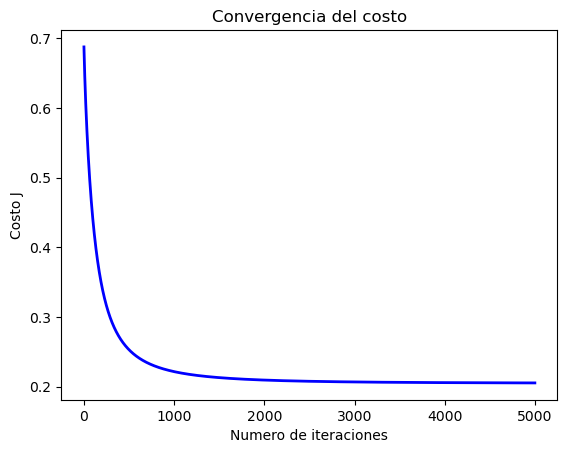

In [18]:
#Gráfica de convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del costo')
pyplot.show()

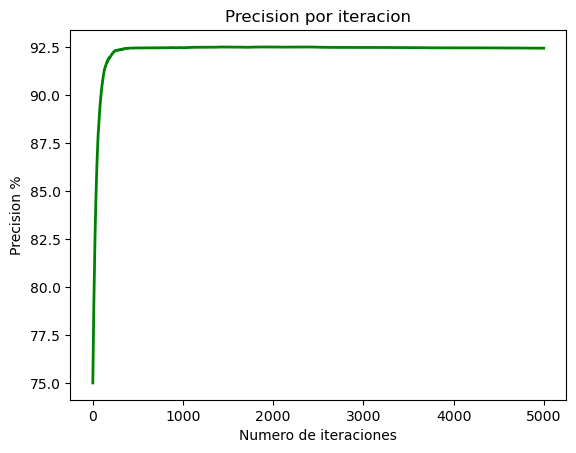

In [19]:
#Gráfica de precisión por iteración
pyplot.plot(np.arange(len(P_history)), P_history, lw=2, color='green')
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Precision %')
pyplot.title('Precision por iteracion')
pyplot.show()

In [26]:
# PREDICCIONES

# Predicciones sobre el set de test
p = predict(theta, X_test_b)

# Precisión en test
precision_test = np.mean(p == y_test) * 100
print(f"Precisión en test: {precision_test:.2f}%")

# Mostrar 100 predicciones vs valores reales
print(f"\n{'#':>4} {'Real':>8} {'Predicho':>10} {'Resultado':>12}")
print("-" * 38)
for i in range(100):
    resultado = 'Correcto' if p[i] == y_test[i] else 'Incorrecto'
    print(f"{i+1:>4} {int(y_test[i]):>8} {int(p[i]):>10} {resultado:>12}")

# Resumen de las 100 predicciones
correctas = np.sum(p[:100] == y_test[:100])
print(f"\nCorrectас: {correctas}/100")
print(f"Incorrectas: {100 - correctas}/100")

Precisión en test: 92.23%

   #     Real   Predicho    Resultado
--------------------------------------
   1        0          0     Correcto
   2        0          0     Correcto
   3        0          0     Correcto
   4        0          0     Correcto
   5        1          0   Incorrecto
   6        0          0     Correcto
   7        0          0     Correcto
   8        0          0     Correcto
   9        0          0     Correcto
  10        0          0     Correcto
  11        0          0     Correcto
  12        1          0   Incorrecto
  13        0          0     Correcto
  14        0          0     Correcto
  15        0          0     Correcto
  16        0          0     Correcto
  17        0          0     Correcto
  18        1          0   Incorrecto
  19        0          0     Correcto
  20        0          0     Correcto
  21        0          0     Correcto
  22        0          0     Correcto
  23        0          0     Correcto
  24        0         

In [22]:
# =============================================
# BLOQUE 10: OPTIMIZADOR SCIPY - ENTRENAMIENTO
# =============================================

def costFunction(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    grad = (1 / m) * (h - y).dot(X)
    return J, grad

initial_theta = np.zeros(X_train_b.shape[1])
options = {'maxfun': 1000}

res = optimize.minimize(costFunction,
                        initial_theta,
                        (X_train_b, y_train),
                        jac=True,
                        method='TNC',
                        options=options)

theta_opt = res.x
costo_train_opt = calcularCosto(theta_opt, X_train_b, y_train)
costo_test_opt = calcularCosto(theta_opt, X_test_b, y_test)

p_opt_train = predict(theta_opt, X_train_b)
precision_train_opt = np.mean(p_opt_train == y_train) * 100

p_opt_test = predict(theta_opt, X_test_b)
precision_test_opt = np.mean(p_opt_test == y_test) * 100

print(f"Costo final en train: {costo_train_opt:.4f}")
print(f"Costo final en test:  {costo_test_opt:.4f}")
print(f"Precisión en train:   {precision_train_opt:.2f}%")
print(f"Precisión en test:    {precision_test_opt:.2f}%")

Costo final en train: 0.2043
Costo final en test:  0.2088
Precisión en train:   92.51%
Precisión en test:    92.17%


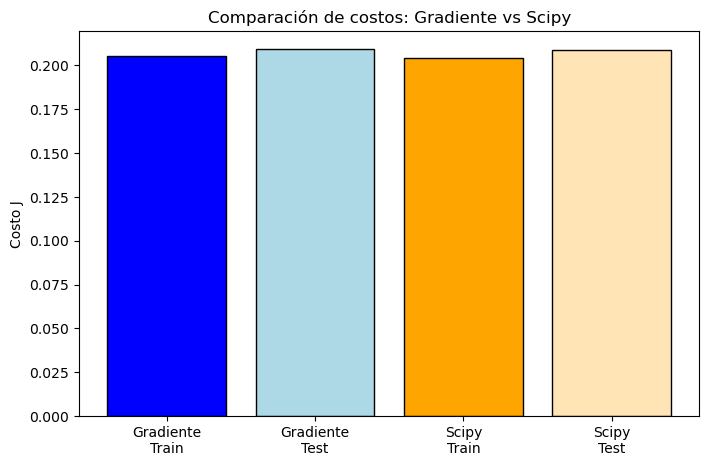

In [23]:
# Comparación de costos: Gradiente vs Scipy
modelos = ['Gradiente\nTrain', 'Gradiente\nTest', 'Scipy\nTrain', 'Scipy\nTest']
costos = [costo_train, costo_test, costo_train_opt, costo_test_opt]
colores = ['blue', 'lightblue', 'orange', 'moccasin']

pyplot.figure(figsize=(8, 5))
pyplot.bar(modelos, costos, color=colores, edgecolor='black')
pyplot.ylabel('Costo J')
pyplot.title('Comparación de costos: Gradiente vs Scipy')
pyplot.show()

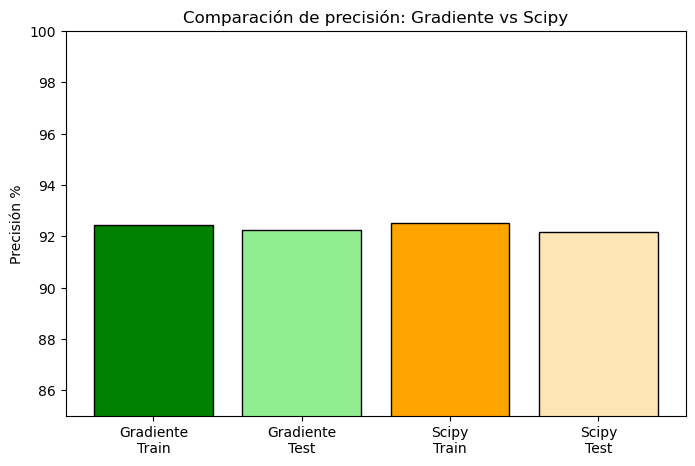

In [24]:
# Comparación de precisión: Gradiente vs Scipy
modelos = ['Gradiente\nTrain', 'Gradiente\nTest', 'Scipy\nTrain', 'Scipy\nTest']
precisiones = [P_history[-1], np.mean(predict(theta, X_test_b) == y_test) * 100,
               precision_train_opt, precision_test_opt]
colores = ['green', 'lightgreen', 'orange', 'moccasin']

pyplot.figure(figsize=(8, 5))
pyplot.bar(modelos, precisiones, color=colores, edgecolor='black')
pyplot.ylabel('Precisión %')
pyplot.title('Comparación de precisión: Gradiente vs Scipy')
pyplot.ylim([85, 100])
pyplot.show()